In [1]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

debugging snellius OOM issue

8GB full dataset pandas in memory from parquet file

ATTEMPT NOW:
n_jobs=1, instead of n_jobs=-1

Hyperparam search once on full dataset and features
utilize hyperparams to retrain feature specific models

Currently saving the best model, and performing predictions on the test set -> should be on seperate training set (2023) for hyperparameters right? 

perform hyperparam search on mini subset? 
1 month still too slow doesnt finish
1 day finishes -> but might not be representative?

LEAVE OUT HYPERPARAM FOR NOW


# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- Hyperparameter: RandomSearchCV full dataset
- Models: LR, XGB, HistBoost (LGBM)
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


NOTES TODO (ASK):

Requiring models that capture both -> do we need to prove dependency (how, by showing correlation with spatial and temporal columns?) pearson correlation in prior work seems not quite right
Correlation with temporal column?

Nonsim = robustness (train on history, predict future)
temporal features only lag features + (transformed) calender info enough? or require time series modeling?

Prediction task: want to add 'to what extent' (multiclass)

# Classification baseline models notebook

## Imports

In [2]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import torch
import matplotlib.pyplot as plt

import duckdb
######################

import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,balanced_accuracy_score, mean_squared_error,r2_score,mean_absolute_error



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
import joblib 
from tqdm import tqdm
from scipy.stats import uniform, randint, loguniform

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap
from sklearn.impute import SimpleImputer 

import gc

## Globals

In [3]:
# GLOBALS
# Set true for snellius job
train_job = True
snellius = True # Set True for snellius, False for local development
shap_plots = False

# Set false for default parameters and
subset_dataset = False
search_param = False #False to utilize model defaults

# available service years 2019, 2020, 2021, 2022, 2023, 2024
TRAINING_FROM_YEAR = 2023

# Misc
partition = "services_full" if snellius else "services_subset"
FILENAME_PARTITION = "test_default_NoShap" if snellius else "SUBSET"
# FILENAME_PARTITION = "test" if subset_dataset else "test_subset"

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

RANDOM_SEED = 88 # For reproducibility
run_analysis = False

In [4]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
	# Change later to snellius $HOME or whatever folder you want to work in
	target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

	# Check if it exists before moving
	if target_root.exists():
		os.chdir(target_root)
		print(f"✅ Success! Moved to: {Path.cwd()}")
	else:
		print(f"❌ Error: The folder '{target_root}' does not exist.")

In [5]:
if snellius is True:
	# Get the home directory path object
	home_dir = Path.home() 

	# Build a path to your code
	target_root = home_dir / "NS_Thesis"

	print(target_root)

/home/jbao/NS_Thesis


## File paths

In [6]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"
final_train_test_data_filtered_filepath = final_data_root / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_final_train_test_data_filtered.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

Connect duckDB database

In [7]:
## Connect to database
db_name = f'{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_main_classifications.duckdb'

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database=db_name) 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
	con.execute("SET memory_limit='5GB'")   

Does file exist? False


## Feature lists

In [8]:
service_features = [
	'source', 'target', 'distance',
]

topology_features = [
	'total_services', 'src_degree', 'src_weighted_degree', 'src_avg_distance', 
	'tgt_degree', 'tgt_weighted_degree', 'tgt_avg_distance', 
	'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
	'adamic_adar_index', 'resource_allocation_index',
]

weather_features = [
	'temperature_2m', 'rain', 'snowfall', 'snow_depth', 
	'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'
]

calendar_features = ['arrival_hour', 'is_holiday', 
 'service_year', 'service_month', 'day_of_week'
 ]

operational_features = ['rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay'
 ]

non_numeric_features = ['source', 
	'target', 
	'service_date', 
	'train_type_counts', 
	'month_name', 
	'day_name']

all_features = service_features + topology_features + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_binary']

features_to_drop = non_numeric_features + [
'total_departure_delay_minutes',
 'avg_departure_delay_minutes','total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services',
 'count_delayed_departure_services',
 'ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'target_multiclass'
 ]

In [9]:
con.execute("DROP VIEW IF EXISTS services_final")

In [10]:
# Convert your list into a comma-separated string for the SQL query
refined_drop_list = list(set(features_to_drop) - {'service_date'})
cols_to_exclude = ", ".join(refined_drop_list)


In [11]:
con.execute(f"""
	CREATE OR REPLACE VIEW services_final AS 
	SELECT * EXCLUDE ({cols_to_exclude})
	FROM read_parquet('{final_data_filepath}') 
	ORDER BY service_date ASC, arrival_hour ASC
""")

## Description dataset

### Column Features

FEATURE LISTS

service_features = [
	'source', 'target', 'distance',
]

topology_features = [
	'total_services', 'src_degree', 'src_weighted_degree', 'src_avg_distance', 
	'tgt_degree', 'tgt_weighted_degree', 'tgt_avg_distance', 
	'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
	'adamic_adar_index', 'resource_allocation_index',
]

weather_features = [
	'temperature_2m', 'rain', 'snowfall', 'snow_depth', 
	'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'
]

calendar_features = ['arrival_hour', 'is_holiday', 'month_name', 'day_name', 
 'service_year',
 'service_month',
 'day_of_week'
 ]

operational_features = ['rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay'
 ]

target_features = ['target_binary', 'target_multiclass']

features_to_drop_list = ['service_date', 'total_departure_delay_minutes',
 'avg_departure_delay_minutes','total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services','ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'train_type_counts',
 ]

['source',
 'target',
 'service_date',
 'arrival_hour',
 'earliest_departure_hour',
 'distance',
 'total_departure_delay_minutes',
 'avg_departure_delay_minutes',
 'count_delayed_departure_services',
 'total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services',
 'total_services',
 'ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'train_type_counts',
 'src_degree',
 'src_weighted_degree',
 'src_avg_distance',
 'tgt_degree',
 'tgt_weighted_degree',
 'tgt_avg_distance',
 'common_neighbors',
 'jaccard_coefficient',
 'preferential_attachment',
 'adamic_adar_index',
 'resource_allocation_index',
 'temperature_2m',
 'rain',
 'snowfall',
 'snow_depth',
 'wind_speed_10m',
 'wind_gusts_10m',
 'soil_temperature_0_to_7cm',
 'is_holiday',
 'target_binary',
 'target_multiclass',
 'count_intercity',
 'count_sprinter',
 'count_other_trains',
 'month_name',
 'day_name',
 'rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay',
 'service_year',
 'service_month',
 'day_of_week']

In [12]:
if run_analysis:
	display(con.execute("DESCRIBE services_final").df().column_name.tolist())

In [13]:
if run_analysis:
	display(con.execute("DESCRIBE services_final").df())

### Class balance analysis

Classes are currently based off avg delay / services on trajectory


trajectories_no_delay: The number of rows (route/hour trajectories) where zero scheduled trains were late.

trajectories_with_delay: The number of rows where at least one scheduled train experienced a delay.

total_individual_services: The grand total of all trains scheduled across the entire dataset (the sum of the total_services column).

total_delayed_services: The actual number of late trains (the sum of the count_delayed_services column).

In [14]:
if run_analysis:
	# Query to calculate trajectory-level stats
	class_balance_stats = con.execute("""
		SELECT 
			COUNT(*) FILTER (WHERE target_binary = 0) as trajectories_no_delay,
			COUNT(*) FILTER (WHERE target_binary = 1) as trajectories_with_delay,
			SUM(total_services) as total_individual_services,
			SUM(count_delayed_services) as total_delayed_services
		FROM services_final
	""").df()

	print(class_balance_stats)

In [15]:
if run_analysis:
	# Data for the pie chart
	labels = ['Serivces on trajectory without delay', 'Services on trajectory with delay']
	sizes = [class_balance_stats.iloc[0]['trajectories_no_delay'], class_balance_stats.iloc[0]['trajectories_with_delay']]
	colors = ['lightgreen', 'salmon']

	# Plot the pie chart
	plt.figure(figsize=(8, 6))
	plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
	plt.title('Planned Services on Trajectories with and without delay (Binary Target)')
	plt.show()

In [16]:
if run_analysis:
	# Query the existing target_multiclass column
	multiclass_distribution = con.execute("""
		SELECT 
			target_multiclass, 
			COUNT(*) AS total_trajectories,
			ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
		FROM services_final
		GROUP BY target_multiclass
		ORDER BY target_multiclass
	""").df()

	print(multiclass_distribution)

In [17]:
if run_analysis:
	# 1. Force the DataFrame to follow the 0, 1, 2, 3 order
	multiclass_distribution = multiclass_distribution.sort_values('target_multiclass')

	# 2. Extract sizes based on that guaranteed order
	sizes = multiclass_distribution['total_trajectories'].tolist()

	# 3. Match labels and colors to that exact sequence
	labels = [
		'On-time/Early (-inf, 0] (0)', 
		'Short (0, 30) min (1)', 
		'Medium [30, 60) min (2)', 
		'Severe [60, inf) min (3)'
	]
	colors = ['lightgreen', 'salmon', 'orange', 'gold']

	plt.figure(figsize=(10, 7))

	plt.pie(sizes, 
			labels=labels, 
			autopct='%1.1f%%', 
			startangle=140, 
			colors=colors, 
			pctdistance=0.85,
			counterclock=False) 

	plt.title('Distribution of Trajectory Delay Classes (Multiclass Target)')
	plt.tight_layout()
	plt.show()

### Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [18]:
if run_analysis:
	# Query to get the total count of unique stations
	unique_stations_count = con.execute("""
		SELECT count(DISTINCT station) 
		FROM (
			SELECT source AS station FROM services_final
			UNION 
			SELECT target AS station FROM services_final
		)
	""").fetchone()[0]

	print(f"Total unique stations: {unique_stations_count}")

## Full dataset

incl. NA values imputation fix fo hours_since_prev_service

In [19]:
con.execute(f"DROP TABLE IF EXISTS {partition}")

In [20]:
if snellius:
	con.execute(f"""
		CREATE OR REPLACE TABLE {partition} AS
		SELECT 
			* REPLACE (
				COALESCE(hours_since_prev_service, 0) AS hours_since_prev_service
			)
		FROM services_final
		WHERE service_year >= {TRAINING_FROM_YEAR}
	""")
	count = con.execute(f"SELECT count(*) FROM {partition}").fetchone()[0]
	print(f"FULL SET created with {count} rows.")

FULL SET created with 8978262 rows.


## SUBSET of whole dataset for testing, replace later by full

In [21]:
if subset_dataset or (snellius is False):
	con.execute(f""" 
		CREATE OR REPLACE TABLE {partition} AS
		SELECT * REPLACE (
				COALESCE(hours_since_prev_service, 0) AS hours_since_prev_service
			)
		FROM services_final
		WHERE service_date >= '2023-12-31' 
		AND service_date <= '2024-01-01'
	""")

	# Verify the count
	count = con.execute(f"SELECT count(*) FROM {partition}").fetchone()[0]
	print(f"Subset created with {count} rows.")


In [22]:
con.execute(f"COPY {partition} TO '{final_train_test_data_filtered_filepath}' (FORMAT PARQUET)")
print("Done! Saved as ", final_train_test_data_filtered_filepath)

Done! Saved as  /home/jbao/NS_Thesis/downloads/data/filtered/final_aggregated/test_default_NoShap_2023_final_train_test_data_filtered.parquet


In [23]:
dataset_df = pd.read_parquet(final_train_test_data_filtered_filepath)

In [24]:
# Identify columns with missing values
missing_counts = dataset_df.isna().sum()
null_columns = missing_counts[missing_counts > 0]
if not null_columns.empty:
	print("\nColumns with missing values:")
	print(null_columns)
else:
	print("\nNo missing values found in any columns.")


Columns with missing values:
common_neighbors             92
jaccard_coefficient          92
preferential_attachment      92
adamic_adar_index            92
resource_allocation_index    92
temperature_2m               10
rain                         10
snowfall                     10
snow_depth                   10
wind_speed_10m               10
wind_gusts_10m               10
soil_temperature_0_to_7cm    10
dtype: int64


In [25]:
dataset_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8978262 entries, 0 to 8978261
Data columns (total 39 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   service_date                            object 
 1   arrival_hour                            int64  
 2   earliest_departure_hour                 int64  
 3   distance                                int32  
 4   total_services                          int64  
 5   src_degree                              int64  
 6   src_weighted_degree                     int64  
 7   src_avg_distance                        float64
 8   tgt_degree                              int64  
 9   tgt_weighted_degree                     int64  
 10  tgt_avg_distance                        float64
 11  common_neighbors                        float64
 12  jaccard_coefficient                     float64
 13  preferential_attachment                 float64
 14  adamic_adar_index                 

In [26]:
# Calculate total bytes
total_bytes = dataset_df.memory_usage(deep=True).sum()

# Convert to GB
print(f"Total Memory Usage: {total_bytes / (1024 ** 3):.2f} GB")

Total Memory Usage: 2.62 GB


## Class balance

In [27]:
# 1. Get the counts dataframe
balance_df = con.execute(f"""
	SELECT 
		target_binary, 
		COUNT(*) as count
	FROM services_final 
	WHERE service_year >= {TRAINING_FROM_YEAR} AND service_year < 2024 
	GROUP BY target_binary
""").df()

# 2. Extract counts (assuming 0 is Negative, 1 is Positive)
neg_count = balance_df.loc[balance_df['target_binary'] == 0, 'count'].values[0] # not delayed
pos_count = balance_df.loc[balance_df['target_binary'] == 1, 'count'].values[0] # delayed

# 3. Store the ratio in a variable
# XGBoost Formula: sum(negative instances) / sum(positive instances)
scale_pos_weight_value_train = neg_count / pos_count

print(f"Negative Count: {neg_count}")
print(f"Positive Count: {pos_count}")
print(f"Recommended scale_pos_weight: {scale_pos_weight_value_train:.2f}")
print(balance_df.info())

Negative Count: 1996712
Positive Count: 2474133
Recommended scale_pos_weight: 0.81
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   target_binary  2 non-null      int32
 1   count          2 non-null      int64
dtypes: int32(1), int64(1)
memory usage: 152.0 bytes
None


In [28]:
con.execute(f"""
	SELECT 
		target_binary, 
		COUNT(*) as count,
		COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() as ratio
	FROM services_final 
	WHERE service_year >= {TRAINING_FROM_YEAR} AND service_year < 2024 
	GROUP BY target_binary
""").df()

,target_binary,count,ratio
0,0,1996712,0.446607
1,1,2474133,0.553393


class 0 class 1

56,1% 43,9% full training dataset

44,7% 55,3% 2023 only


## Initialize models

### Hyperparameter search 
NOTE: We adopt best param of prior work instead for now 

But be aware of different data (distribution and class balance)

In [29]:
if train_job and search_param:
	# ==========================================
	# 1. SETUP & DATA LOADING
	# ==========================================

	models_folder = models_folder
	if not os.path.exists(models_folder):
		os.makedirs(models_folder)

	# RANDOM SEED
	RANDOM_SEED = 88

	# ### ACTION REQUIRED: Load your dataset here ###

	df = dataset_df
	target_col = 'target_binary'
	time_col = 'service_year'  

	# ==========================================
	# 2. TEMPORAL SPLIT & PREPROCESSING
	# ==========================================

	# 1. Sort by Time# Sort by Date first, then by Hour within that date
	df = df.sort_values(by=['service_date', 'arrival_hour']).reset_index(drop=True)
	df = df.drop(columns=['service_date'])

	split_threshold = 2024  # Train on data before 2023, Test on 2024

	feature_cols = [c for c in df.columns if c not in [target_col, time_col]]

	# 2. Encode Categoricals and bools
	bool_cols = df[feature_cols].select_dtypes(include=['bool']).columns
	for col in bool_cols:
		df[col] = df[col].astype(int)

	# 3. Create Split Mask
	train_mask = df[time_col] < split_threshold
	test_mask = df[time_col] >= split_threshold

	X_train = df.loc[train_mask, feature_cols]
	y_train = df.loc[train_mask, target_col]
	X_test = df.loc[test_mask, feature_cols]
	y_test = df.loc[test_mask, target_col]

	# 4. Calculate Imbalance ratio (for XGBoost)
	scale_pos_weight_value = scale_pos_weight_value_train

	print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")
	print(f"Imbalance Ratio (Neg/Pos): {scale_pos_weight_value:.2f}")

	# ==========================================
	# 3. HYPERPARAMETER GRIDS (Updated)
	# ==========================================

	tscv = TimeSeriesSplit(n_splits=5) 

	param_grids = {
		"Logistic_Regression": {
			# PIPELINE: Scales data ONLY for this model
			"model": Pipeline([
				('imputer', SimpleImputer(strategy='median')), # TODO check later full dataset
				('scaler', StandardScaler()), 
				('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED, max_iter=1000))
			]),
			# NOTE: Params must now use 'clf__' prefix to target the classifier step
			"params": {
				'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
				'clf__penalty': ['l1', 'l2', 'elasticnet'], 
				'clf__solver': ['liblinear', 'saga', 'newton-cg'], 
			}
		},
		# "Random_Forest": {
		#	 "model": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
		#	 "params": {
		# 		'n_estimators': [100, 200, 500, 1000],
		# 		'max_features': ['auto', 'sqrt', 'log2'],
		# 		'max_depth': [10, 20, 30, None],
		# 		'min_samples_split': [2, 5, 10],
		# 		'min_samples_leaf': [1, 2, 4],
		# 		'bootstrap': [True, False]
		#	 }
		# },
		"XGBoost": {
			"model": XGBClassifier(eval_metric='logloss', random_state=RANDOM_SEED, n_jobs=-1),
			"params": {
				'max_depth': [3, 5, 7],
				'learning_rate': [0.01, 0.1, 0.3],	  
				'n_estimators': [100, 200, 300],
				'subsample': [0.6, 0.8, 1.0],
				'colsample_bytree': [0.6, 0.8, 1.0],
				'scale_pos_weight': [1, scale_pos_weight_value]
			}
		},
		"HistGradientBoosting": {
			"model": HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_SEED),
			"params": {
				'max_depth': [3, 5, 7],
				'learning_rate': [0.01, 0.1, 0.3],
				'max_iter': [100, 200, 300], # Equivalent to n_estimators
				'max_leaf_nodes': [15, 32, 64], 
				'l2_regularization': [0, 0.1, 1.0, 10]
			}
		}
	}
	


	scoring = {
		'balanced_accuracy': make_scorer(balanced_accuracy_score),
		'f1': make_scorer(f1_score),
		'precision': make_scorer(precision_score),
		'recall': make_scorer(recall_score),
		'roc_auc': make_scorer(roc_auc_score)
	}

	# ==========================================
	# 4. TUNING LOOP & SAVING
	# ==========================================

	results = []
	print(f"\nStarting Randomized Search and Saving Results to '{models_folder}'...")


	for name, config in param_grids.items(): 
		print(f"\n--- Tuning {name} ---")
		
		# Run Search
		search = RandomizedSearchCV(
			estimator=config["model"],
			param_distributions=config["params"],
			n_iter=10,		   
			scoring=scoring,
			refit='f1',			
			cv=tscv, 
			verbose=1,
			n_jobs=1, 
			random_state=RANDOM_SEED,
			pre_dispatch='2*n_jobs'
		)
		
		search.fit(X_train, y_train)
		best_model = search.best_estimator_
		

		# --- PRINT BEST PARAMETERS (ADDED) ---
		print(f"   > Best Params: {search.best_params_}")
		print(f"   > Best CV Score: {search.best_score_:.4f}")

		# --- SAVE MODEL ---
		model_filename = f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_{name}_best.pkl"
		model_filepath = models_folder / model_filename
		joblib.dump(best_model, model_filepath)
		
		# Predict
		y_pred = best_model.predict(X_test)
		
		# Calculate Metrics
		f1 = f1_score(y_test, y_pred)
		bal_acc = balanced_accuracy_score(y_test, y_pred)
		
		try:
			y_prob = best_model.predict_proba(X_test)[:, 1]
			auc = roc_auc_score(y_test, y_prob)
		except:
			auc = 0
			
		results.append({
			"Model": name,
			"Balanced Accuracy": bal_acc,
			"F1 Score": f1,
			"AUC-ROC": auc,
			"Best Params": search.best_params_,
			"Saved File": model_filename
		})
		del search
		gc.collect()

	# ==========================================
	# 5. RESULTS SAVING & VISUALIZATION
	# ==========================================

	results_df = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)

	# --- SAVE RESULTS TO CSV ---
	results_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_model_results.csv"
	results_df.to_csv(results_path, index=False)
	print(f"\nResults saved to: {results_path}")

	print("\n--- Model Performance (Sorted by Balanced Accuracy) ---")
	# Using tabulate format or simpler string conversion for readability
	print(results_df[['Model', 'Balanced Accuracy', 'F1 Score', 'AUC-ROC']].to_string(index=False))

	# Plotting Balanced Accuracy
	plt.figure(figsize=(10, 6))
	sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")
	plt.title("Model Comparison (Balanced Accuracy)")
	plt.xlim(0, 1.0) 
	plt.show()

	# Show report for winner
	winner = results_df.iloc[0]
	print(f"\nWinner: {winner['Model']} (File: {winner['Saved File']})")


## shap values with model hyperparameters

In [30]:
if train_job and search_param and shap_plots:
	# ==========================================
	# 6. ROBUST SHAP ANALYSIS (Handles Pipelines & Raw Models)
	# ==========================================

	print("\n--- Running SHAP Analysis on the Winner ---")
	results_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_model_results.csv"
	results_df = pd.read_csv(results_path)

	# 1. Identify and Load the Winner
	winner_row = results_df.iloc[0]
	winner_name = winner_row['Model']
	winner_file = winner_row['Saved File']
	best_model = joblib.load(os.path.join(models_folder, winner_file))

	print(f"Winner: {winner_name}")

	# 2. Extract Model & Preprocessor Safely
	# ---------------------------------------------------------
	if hasattr(best_model, 'named_steps'):
		# CASE A: It is a Pipeline (e.g., Logistic Regression)
		print("   > Detected Pipeline structure.")
		preprocessor = best_model.named_steps['preprocessor'] if 'preprocessor' in best_model.named_steps else best_model.named_steps['scaler']
		model_step = best_model._final_estimator
		
		# Transform Test Data for SHAP
		X_test_transformed = preprocessor.transform(X_test)
		
		# Try to get feature names
		try:
			feature_names = preprocessor.get_feature_names_out()
		except:
			feature_names = X_test.columns
			
	else:
		# CASE B: It is a Raw Model (e.g., HistGradient, XGBoost)
		print("   > Detected Raw Model structure.")
		preprocessor = None
		model_step = best_model
		
		# Use raw test data
		X_test_transformed = X_test
		feature_names = X_test.columns

	# 3. Generate SHAP Values
	# ---------------------------------------------------------
	import shap

	print(f"   > Explaining with {type(model_step).__name__}...")

	try:
		if "Logistic" in winner_name or "Linear" in str(type(model_step)):
			# Linear Explainer (Needs background data)
			if preprocessor:
				X_train_transformed = preprocessor.transform(X_train)
			else:
				X_train_transformed = X_train
				
			# Summarize background to 100 samples to prevent crash
			masker = shap.maskers.Independent(data=X_train_transformed, max_samples=100)
			explainer = shap.LinearExplainer(model_step, masker=masker)
			shap_values = explainer.shap_values(X_test_transformed)

		elif "Hist" in winner_name:
			# HistGradientBoosting doesn't work with TreeExplainer efficiently
			# Use Permutation Explainer (Slow but universal)
			print("   > Note: Using PermutationExplainer (this is slower)...")
			
			# # Limit rows to 300 for speed
			# subset_test = X_test_transformed[:300]
			explainer = shap.TreeExplainer(model_step)
			shap_values = explainer(X_test_transformed)

		else:
			# XGBoost / Random Forest (Standard TreeExplainer)
			explainer = shap.TreeExplainer(model_step)
			shap_values = explainer.shap_values(X_test_transformed)

		# 4. Plot & Save
		# ---------------------------------------------------------
		plt.figure(figsize=(10, 8))
		
		# Handle SHAP return types
		if isinstance(shap_values, list):
			# Binary classification list [Neg, Pos] -> Plot Pos
			vals_to_plot = shap_values[1]
		elif hasattr(shap_values, 'values'):
			# PermutationExplainer returns an object with .values
			vals_to_plot = shap_values
		else:
			vals_to_plot = shap_values

		shap.summary_plot(vals_to_plot, X_test_transformed[:len(vals_to_plot)], feature_names=feature_names, show=False)
		
		save_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_SHAP_Summary_{winner_name}.png"
		plt.savefig(save_path, bbox_inches='tight', dpi=300)
		plt.close()
		print(f"   > Saved SHAP plot to: {save_path}")

	except Exception as e:
		print(f"   [!] SHAP Analysis Failed: {e}")
		print("	   (This often happens with HistGradientBoosting due to library incompatibilities)")

## (default) MODEL TRAINING

Training Samples: 4470845 | Testing Samples: 4507417
Imbalance Ratio (Neg/Pos): 0.81

Starting Model Training and eval Saving Results to '/home/jbao/NS_Thesis/models'...

--- Tuning Logistic_Regression ---


   > Balanced Acc: 0.6905 | F1: 0.7105 | AUC: 0.7661

Classification Report (Logistic_Regression):


              precision    recall  f1-score   support

           0       0.65      0.69      0.67   2047422
           1       0.73      0.69      0.71   2459995

    accuracy                           0.69   4507417
   macro avg       0.69      0.69      0.69   4507417
weighted avg       0.69      0.69      0.69   4507417


--- Tuning XGBoost ---


/home/jbao/.conda/envs/my_research_env/lib/python3.10/site-packages/xgboost/core.py:750: UserWarning: [23:25:37] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1767713912275/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


   > Balanced Acc: 0.7208 | F1: 0.7359 | AUC: 0.8029

Classification Report (XGBoost):


              precision    recall  f1-score   support

           0       0.68      0.73      0.70   2047422
           1       0.76      0.71      0.74   2459995

    accuracy                           0.72   4507417
   macro avg       0.72      0.72      0.72   4507417
weighted avg       0.72      0.72      0.72   4507417


--- Tuning HistGradientBoosting ---


   > Balanced Acc: 0.7223 | F1: 0.7361 | AUC: 0.8043

Classification Report (HistGradientBoosting):


              precision    recall  f1-score   support

           0       0.68      0.73      0.70   2047422
           1       0.76      0.71      0.74   2459995

    accuracy                           0.72   4507417
   macro avg       0.72      0.72      0.72   4507417
weighted avg       0.72      0.72      0.72   4507417


Results saved to: /home/jbao/NS_Thesis/results/test_default_NoShap_2023_model_results.csv

--- Model Performance (Sorted by Balanced Accuracy) ---
               Model  Balanced Accuracy  F1 Score  AUC-ROC
HistGradientBoosting           0.722261  0.736106 0.804311
             XGBoost           0.720817  0.735886 0.802889
 Logistic_Regression           0.690499  0.710505 0.766108


/scratch-local/jbao.19617535/ipykernel_353342/2344976717.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")


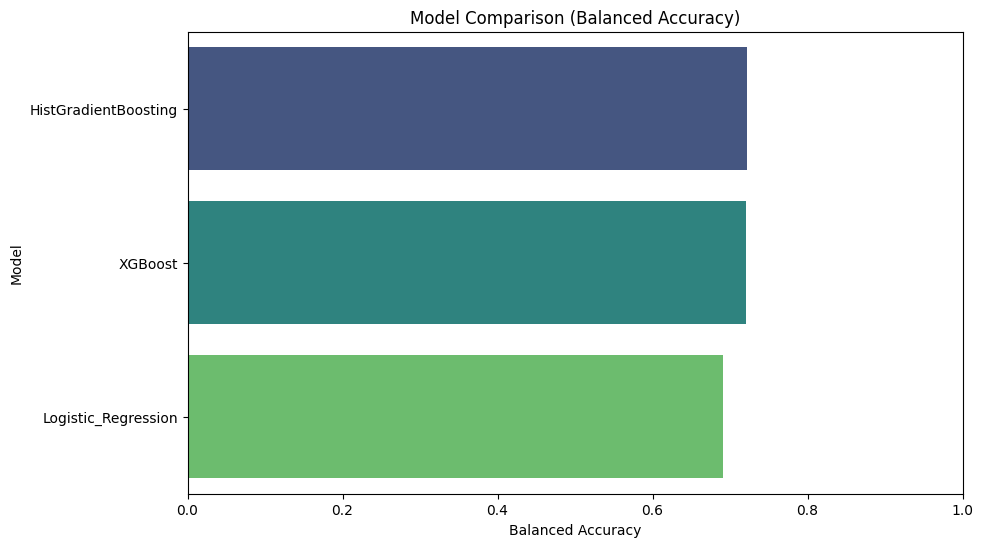


Winner: HistGradientBoosting (File: test_default_NoShap_2023_HistGradientBoosting_best.pkl)


In [31]:
if train_job and (search_param is False):
	# ==========================================
	# 1. SETUP & DATA LOADING
	# ==========================================

	models_folder = models_folder
	if not os.path.exists(models_folder):
		os.makedirs(models_folder)

	# ### ACTION REQUIRED: Load your dataset here ###

	df = dataset_df
	target_col = 'target_binary'
	time_col = 'service_year'  

	# ==========================================
	# 2. TEMPORAL SPLIT & PREPROCESSING
	# ==========================================

	# 1. Sort by Time# Sort by Date first, then by Hour within that date

	if 'service_date' in df.columns:
		df = df.sort_values(by=['service_date', 'arrival_hour']).reset_index(drop=True)
		df = df.drop(columns=['service_date'])
	else:
		df = df.sort_values(by=['service_year']).reset_index(drop=True)

	split_threshold = 2024  # Train on data before 2023, Test on 2024

	feature_cols = [c for c in df.columns if c not in [target_col, time_col]]

	# 2. Encode Categoricals and bools
	bool_cols = df[feature_cols].select_dtypes(include=['bool']).columns
	for col in bool_cols:
		df[col] = df[col].astype(int)

	# 3. Create Split Mask
	train_mask = df[time_col] < split_threshold
	test_mask = df[time_col] >= split_threshold

	X_train = df.loc[train_mask, feature_cols]
	y_train = df.loc[train_mask, target_col]
	X_test = df.loc[test_mask, feature_cols]
	y_test = df.loc[test_mask, target_col]

	# 4. Calculate Imbalance ratio (for XGBoost)
	scale_pos_weight_value = scale_pos_weight_value_train

	print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")
	print(f"Imbalance Ratio (Neg/Pos): {scale_pos_weight_value:.2f}")

	# ==========================================
	# 3. DEFINE MODELS (FIXED PARAMETERS)
	# ==========================================

	models = {
		"Logistic_Regression": Pipeline([
			('imputer', SimpleImputer(strategy='median')), # TODO: fix more NA's, placeholder for now
			('scaler', StandardScaler()),  # Handles outliers better than mixmax
			('clf', LogisticRegression(
				class_weight='balanced', # Account for class imbalance
				solver='saga', # SGD algo, faster for larger datasets
				max_iter=1000, # Default=100, larger for convergence
				random_state=RANDOM_SEED # Reproducibility due to saga solver
				)
				)
		]),
		
		"XGBoost": XGBClassifier(
			device=xgb_device,
			eval_metric='logloss',	  # Binary Classification
			n_estimators=100,		 # Cap the trees to save time
			max_depth=6,			  # Standard default
			learning_rate=0.1,		# Default=0.3, set lower to prevent overshooting
			scale_pos_weight=scale_pos_weight_value,  # Default=1, account for class imbalance to full train dataset ratio
			n_jobs=-1,				
			random_state=RANDOM_SEED
		),
		
		"HistGradientBoosting": HistGradientBoostingClassifier(
			class_weight='balanced',  # Account for class imbalance
			max_iter=100,			 # Standard default
			random_state=RANDOM_SEED
		)
	}

	# ==========================================
	# 4. TUNING LOOP & SAVING
	# ==========================================

	results = []
	print(f"\nStarting Model Training and eval Saving Results to '{models_folder}'...")


	for name, model in models.items(): 
		print(f"\n--- Tuning {name} ---")
		
		# Run Search
		
		model.fit(X_train, y_train)

		# --- SAVE MODEL ---
		model_filename = f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_{name}_best.pkl"
		model_filepath = models_folder / model_filename
		joblib.dump(model, model_filepath)
		
		# Predict
		y_pred = model.predict(X_test)
		
		# Calculate Metrics
		f1 = f1_score(y_test, y_pred)
		bal_acc = balanced_accuracy_score(y_test, y_pred)
		
		try:
			if hasattr(model, "predict_proba"):
				y_prob = model.predict_proba(X_test)[:, 1]
			else:
				y_prob = model.named_steps['clf'].predict_proba(X_test)[:, 1]
			auc = roc_auc_score(y_test, y_prob)
		except:
			auc = 0
		
		print(f"   > Balanced Acc: {bal_acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
		print(f"\nClassification Report ({name}):")
		print(classification_report(y_test, y_pred))
			
		results.append({
			"Model": name,
			"Balanced Accuracy": bal_acc,
			"F1 Score": f1,
			"AUC-ROC": auc,
			"Saved File": model_filename
		})
		del model
		gc.collect()

	# ==========================================
	# 5. RESULTS SAVING & VISUALIZATION
	# ==========================================

	results_df = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)

	# --- SAVE RESULTS TO CSV ---
	results_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_model_results.csv"
	results_df.to_csv(results_path, index=False)
	print(f"\nResults saved to: {results_path}")

	print("\n--- Model Performance (Sorted by Balanced Accuracy) ---")
	# Using tabulate format or simpler string conversion for readability
	print(results_df[['Model', 'Balanced Accuracy', 'F1 Score', 'AUC-ROC']].to_string(index=False))

	# Plotting Balanced Accuracy
	plt.figure(figsize=(10, 6))
	sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")
	plt.title("Model Comparison (Balanced Accuracy)")
	plt.xlim(0, 1.0) 
	plt.show()

	# Show report for winner
	winner = results_df.iloc[0]
	print(f"\nWinner: {winner['Model']} (File: {winner['Saved File']})")


In [32]:
if train_job and shap_plots and (search_param is False):
    print("\n================================================")
    print("   RUNNING SHAP ON ALL TRAINED MODELS   ")
    print("================================================")
    
    import shap
    import gc
    import matplotlib.pyplot as plt
    
    # 1. Load Results
    results_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_model_results.csv"
    results_df = pd.read_csv(results_path)

    # 2. Loop through every model in the CSV
    for index, row in results_df.iterrows():
        model_name = row['Model']
        model_file = row['Saved File']
        
        print(f"\n--- Processing Model: {model_name} ---")
        
        try:
            # Load model
            current_model = joblib.load(os.path.join(models_folder, model_file))

            # ---------------------------------------------------------
            # 3. Extract Model & Prepare Data
            # ---------------------------------------------------------
            feature_names = None
            X_shap = X_test  # Default to raw data

            if isinstance(current_model, Pipeline):
                print(" > Detected Pipeline. Pre-processing full test set...")
                preprocessor = current_model[:-1] 
                model_step = current_model._final_estimator
                
                # Transform ALL rows
                X_shap = preprocessor.transform(X_test)
                
                try:
                    feature_names = preprocessor.get_feature_names_out()
                except:
                    feature_names = X_test.columns
            else:
                print(" > Detected Raw Model.")
                model_step = current_model
                feature_names = X_test.columns

            # ---------------------------------------------------------
            # 4. Configure Explainer
            # ---------------------------------------------------------
            print(f" > Initializing Explainer for {len(X_shap)} rows...")
            vals_to_plot = None
            
            # CASE A: Linear (Logistic Regression) 
            if "Logistic" in model_name or "Linear" in str(type(model_step)):
                print(" > Using LinearExplainer...")
                
                if isinstance(current_model, Pipeline):
                    X_train_summary = preprocessor.transform(X_train.sample(1000, random_state=RANDOM_SEED))
                else:
                    X_train_summary = X_train.sample(1000, random_state=RANDOM_SEED)
                    
                explainer = shap.LinearExplainer(model_step, X_train_summary)
                shap_values = explainer.shap_values(X_shap)
                
                vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

            # CASE B: XGBoost 
            elif "XGB" in model_name:
                print(" > Using TreeExplainer...")
                explainer = shap.TreeExplainer(model_step)
                shap_values = explainer.shap_values(X_shap, check_additivity=False)
                vals_to_plot = shap_values

            # CASE C: HistGradientBoosting (As requested: Standard TreeExplainer)
            elif "Hist" in model_name:
                print(" > Using TreeExplainer...")
                explainer = shap.TreeExplainer(model_step)
                shap_values = explainer.shap_values(X_shap, check_additivity=False)
                vals_to_plot = shap_values 

            # ---------------------------------------------------------
            # 5. Plotting
            # ---------------------------------------------------------
            if vals_to_plot is not None:
                print(f" > Generating Summary Plot for {model_name}...")
                
                plt.figure(figsize=(10, 8))
                
                # Handle 3D output if necessary (Samples, Features, Classes)
                if hasattr(vals_to_plot, 'ndim') and vals_to_plot.ndim == 3:
                     vals_to_plot = vals_to_plot[:, :, 1]

                shap.summary_plot(
                    vals_to_plot, 
                    X_shap, 
                    feature_names=feature_names, 
                    show=False,
                    max_display=20
                )
                
                save_path = results_folder / f"{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}_SHAP_Full_{model_name}.png"
                plt.savefig(save_path, bbox_inches='tight', dpi=300)
                plt.close()
                print(f" > Saved plot to: {save_path}")

            # Cleanup memory for local
            del current_model, explainer, shap_values, vals_to_plot
            gc.collect()

        except Exception as e:
            print(f" [!] Error processing {model_name}: {e}")
            # Continue to the next model even if this one fails
            continue

# PRIOR WORK 

Lei's/Merels

1. Find best parameters per model, RandomizedSearchCV=10 TimeSeriesSplit n_split = data of years in training, on parameter grid (full train dataset)

2. Data Splitting: The "Trajectory" Split
Function: get_trajectory_slice

What they did: Instead of randomly splitting rows (e.g., taking 70% of all data points), they split by Trajectory (Source-Target pairs).

Train Set: All data for 70% of the routes (e.g., Amsterdam -> Utrecht).
Test Set: All data for the other 30% of the routes (e.g., Rotterdam -> Hague).

3. Feature Grouping (Ablation Study)
Functions: 

BTF (Binary Topological Features): Simple connection metrics (Common Neighbors, Jaccard).
WTF (Weighted Topological Features): Connection metrics that consider weight/intensity.
NCM (Node Centrality Metrics): Importance of the stations (Degree, Closeness).

4. Experiment A: Simultaneous Testing (The "Now" Test)
Function: simultaneous_test
Loop through every time horizon T. For each T, train on 70% of the edges in T and utilize 30% as test. This means for our hourly dataset too many -> can we randomly sample few hours in the dataset to test this instead of every hour? To check features without any temporal aspect. It eliminates the variable of time. If the model fails here, the features are useless. 
-> do we need randomundersampler?

model_null: Trained "dummy" on shuffled data. Real model atleast should be better than this random chance.

5. Experiment B: Non-Simultaneous Testing (The "Future" Test)
Function: nonsimultaneous_test

Train on Month X.
Test on Month X, Month X+1, Month X+2...

Testing Generalization across time

Can a model trained on January's network topology predict delays in March?

If metrics drop -> model drift, needs retraining. Tests robustness over time

6. Explainability: SHAP Analysis (on test sets) -> HOW it works
Function: all_shap_values

Workflow
Tune: Find best hyperparameters.
Split: Separate data by Route (Space).
Group: Pick a feature set (e.g., BTF).
Validate (Space, stimulous): Test on new routes in the same month.
Validate (Time, non stimulous): Test on new routes in future months.
Explain: Calculate SHAP to rank feature importance.

In [33]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
#	 df = data
#	 trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#	 random.seed(seed)
#	 train_size = int(f_train_e * len(trajectories))
#	 random.shuffle(trajectories)
#	 train_trajectories = set(trajectories[:train_size])
#	 test_trajectories = set(trajectories[train_size:])
	
#	 df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#	 df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
	
#	 return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
#	 X = df.loc[:, features].to_numpy()
#	 y = df.loc[:, target].to_numpy()
#	 return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_simultaneous'
#	 else:
#		 name = name + '_simultaneous'
	
#	 year_month_list = sorted(df_train['YearMonth'].unique())
#	 res_df_test = df_test.copy()
#	 res_df_test['simultaneous_pred'] = np.nan
#	 res_df_test['simultaneous_null'] = np.nan
	
#	 for year_month in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
#		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
#		 y_train_null = y_train.copy()
#		 np.random.shuffle(y_train_null)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 model_null = XGBClassifier(**best_params)
#		 model_null.fit(X_train, y_train_null)
		
#		 y_pred = model.predict(X_test)
#		 y_pred_null = model_null.predict(X_test)
		
#		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#		 res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
	
#	 if save:
#		 res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
	
#	 return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#	 else:
#		 name = name + '_nonsimultaneous'
	
#	 year_month_list = sorted(df_test['YearMonth'].unique())
#	 preds = []
	
#	 for year_month_train in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
		
#		 y_train_null = y_train.copy()
#		 np.random.shuffle(y_train_null)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 model_null = XGBClassifier(**best_params)
#		 model_null.fit(X_train, y_train_null)
		
#		 for year_month_test in year_month_list:
#			 if year_month_test < year_month_train:
#				 continue
#			 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#			 y_pred = model.predict(X_test)
#			 y_null = model_null.predict(X_test)
#			 preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
	
#	 if save:
#		 import pickle
#		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#			 pickle.dump(preds, f)
	
#	 return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#	 if name is None:
#		 name = ''.join([w[0] for w in features]) + '_SHAP'
#	 else:
#		 name = name + '_SHAP'
	
#	 def get_temporal_order(shap_list):
#		 importance_array = []
#		 for shap_values in shap_list:
#			 array = -np.abs(shap_values).mean(axis=0)
#			 ranks = ss.rankdata(array)
#			 importance_array.append(ranks)
#		 return np.array(importance_array)

#	 shap_values_list = []
#	 test_list = []
#	 year_month_list = sorted(df_test['YearMonth'].unique())
	
#	 for year_month in tqdm(year_month_list):
#		 X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#		 ros = RandomUnderSampler()
#		 X_train, y_train = ros.fit_resample(X_train, y_train)
#		 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
		
#		 model = XGBClassifier(**best_params)
#		 model.fit(X_train, y_train)
#		 explainer = shap.TreeExplainer(model)
#		 shap_values = explainer.shap_values(X_test)
		
#		 test_list.append(pd.DataFrame(X_test, columns=features))
#		 shap_values_list.append(shap_values)
	
#	 if save:
#		 import pickle
#		 with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#			 pickle.dump((test_list, year_month_list, shap_values_list), f)
	
#	 return test_list, year_month_list, shap_values_list

# def BTF(train, test):
#	 name = 'NS_Classification_BTF'
#	 features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
#	 name = 'NS_Classification_WTF'
#	 features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
#				 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
#	 name = 'NS_Classification_NCM'
#	 features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
#	 simultaneous_test(train, test, features, best_params, name=name)
#	 nonsimultaneous_test(train, test, features, best_params, name=name)
#	 all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
#	 global best_params
#	 best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#					'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#					'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

#	 data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
#	 data = pd.read_csv(data_path)
#	 data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
	
#	 train, test = get_trajectory_slice(data)
#	 BTF(train, test)
#	 WTF(train, test)
#	 NCM(train, test)
